In [1]:
# `os` lets us configure the Keras backend before importing Keras.
import os

# Use PyTorch as the backend for Keras on the current deep-learning environment.
os.environ["KERAS_BACKEND"] = "torch"

# NumPy handles multidimensional numerical arrays.
import numpy as np

# Matplotlib displays images and training curves.
import matplotlib.pyplot as plt

# Seaborn is used for the confusion-matrix heatmap.
import seaborn as sns

# Keras is the high-level deep-learning framework.
import keras

# Sequential builds a model as an ordered stack of layers.
# Model is used later to expose an intermediate CNN layer.
from keras.models import Sequential, Model

# Input defines the shape of one input example.
# Rescaling converts RGB pixel values from 0–255 to 0–1.
# Flatten converts a multidimensional tensor into one vector.
# Dense is a fully connected layer.
# Conv2D learns spatial filters from images.
# MaxPooling2D reduces spatial dimensions.
# Dropout is an optional regularization technique.
# RandomFlip/Translation/Rotation/Zoom are optional data-augmentation layers.
from keras.layers import (
    Input,
    Rescaling,
    Flatten,
    Dense,
    Conv2D,
    MaxPooling2D,
    Dropout,
    RandomFlip,
    RandomTranslation,
    RandomRotation,
    RandomZoom,
    RandomCrop,
    RandomContrast,
    RandomBrightness,
    RandomShear,
    RandomErasing,
    GlobalAveragePooling2D

)

# Adam updates the network weights using gradients.
from keras.optimizers import Adam

from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler

# Sparse categorical cross-entropy is appropriate for integer class labels 0–9.
from keras.losses import SparseCategoricalCrossentropy

# CIFAR-10 provides 32×32 RGB images in 10 classes.
from keras.datasets import cifar10

# This creates the validation subset from the original training data.
from sklearn.model_selection import train_test_split

# These functions provide detailed classification diagnostics.
from sklearn.metrics import classification_report, confusion_matrix

# Verify the environment before training.
print("Keras version:", keras.__version__)
print("Keras backend:", keras.backend.backend())


Keras version: 3.15.1
Keras backend: torch


In [2]:
# Load the dataset exactly once.
# `_full` makes it clear that these are the original 50,000 training-side images.
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# CIFAR-10 labels arrive with shape (N, 1).
# Convert them to simple one-dimensional arrays: (N,).
y_train_full = y_train_full.squeeze()
y_test = y_test.squeeze()

# Split the original 50,000 images into 80% training and 20% validation.
# `stratify` keeps approximately equal class proportions in both subsets.
# `random_state=1` makes the split reproducible.
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.20,
    random_state=1,
    stratify=y_train_full,
)

# Display all shapes before any model is trained.
print("Train:     ", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:      ", x_test.shape, y_test.shape)

# Stop immediately if the data structure is not the one expected.
assert x_train.shape == (40000, 32, 32, 3)
assert x_val.shape == (10000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)

# CIFAR-10 uses RGB pixel intensities from 0 to 255.
print("Pixel range:", x_train.min(), "to", x_train.max())
print("Data type:", x_train.dtype)


Train:      (40000, 32, 32, 3) (40000,)
Validation: (10000, 32, 32, 3) (10000,)
Test:       (10000, 32, 32, 3) (10000,)
Pixel range: 0 to 255
Data type: uint8


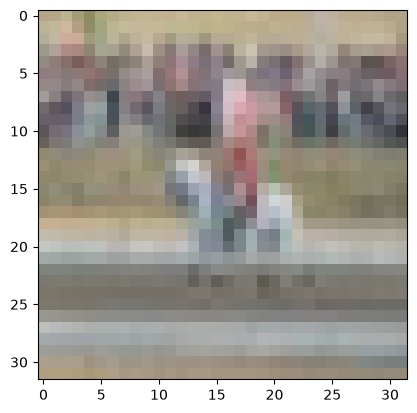

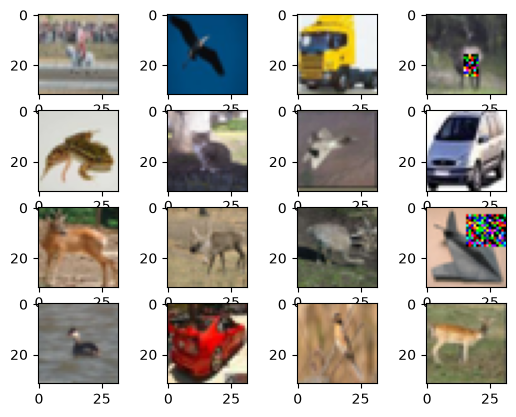

In [3]:
data_augmenter = Sequential([
    RandomFlip("horizontal"),
    RandomErasing(factor=(0.02, 0.33))
])

sample_batch = x_train[:16]

img_augmented = data_augmenter(sample_batch, training=True).cpu().numpy().astype(np.uint8)
img_augmented.shape
plt.imshow(img_augmented[0])
plt.show()

plt.Figure(figsize=(15, 15))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(img_augmented[i])
    #plt.axis("off")
plt.show()

In [4]:
# Build either a clean CNN or, later, a regularized version.
def build_cnn_model(
    use_augmentation: bool = False,
    dropout_rate: float = 0.0,
) -> Sequential:

    # Layers common to all versions.
    layers = [
        # CIFAR-10 already has shape 32×32×3.
        Input(shape=(32, 32, 3)),

        # Convert RGB values from 0–255 to 0–1.
        Rescaling(1.0 / 255),
        
    ]

    # Add augmentation only when explicitly requested.
    if use_augmentation:
        layers.extend([
            # Horizontal flipping is usually class-preserving for CIFAR-10 objects.
            RandomFlip("horizontal"),
            RandomErasing(factor=(0.02, 0.33))
            # RandomErasing(factor=(0.5, 0.25))
            # Shift the object slightly within the image.
            #RandomTranslation(height_factor=0.10, width_factor=0.10),

            # Apply a small random rotation.
            #RandomRotation(factor=0.05),

            # Apply a small random zoom.
            #RandomZoom(height_factor=0.10, width_factor=0.10),
        ])

    # CNN feature extraction.
    layers.extend([
        # 64 learned 3×3 filters; spatial size remains 32×32.
        Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),

        # Learn 128 further feature maps from the previous 64 channels.
        Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),

        # Reduce spatial dimensions: 32×32 → 16×16.
        MaxPooling2D(pool_size=(2, 2)),

        # Increase feature depth from 32 to 64.
        Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),

        # Learn more complex combinations of those features.
        Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),

        # Reduce spatial dimensions: 16×16 → 8×8.
        MaxPooling2D(pool_size=(2, 2)),

        # Increase feature depth again.
        Conv2D(256, kernel_size=(3, 3), activation="relu", padding="same"),

        # Reduce spatial dimensions: 8×8 → 4×4.
        MaxPooling2D(pool_size=(2, 2)),
        GlobalAveragePooling2D(),

        # Convert 4×4×128 feature maps into one vector.
        # Flatten(),
        # Flatten(),

        # Combine extracted features for classification.
        # Dense(128, activation="relu"),

        # Combine extracted features for classification.
        # Dense(128, activation="relu"),
    ])

    # Add Dropout only for the regularized experiment.
    if dropout_rate > 0:
        layers.append(Dropout(dropout_rate))

    # Final 10-class probability output.
    layers.append(Dense(10, activation="softmax"))

    model = Sequential(layers)

    # Configure training.
    model.compile(
        optimizer=Adam(),
        loss=SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    return model


In [5]:
# Plot training and validation accuracy/loss
# and print the main numbers needed to diagnose the model.
def plot_training_history(history, model_name="Model"):

    # Extract the values saved after every epoch.
    train_acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    # Find the epoch with the lowest validation loss.
    best_epoch = np.argmin(val_loss) + 1

    print(f"Best validation-loss epoch: {best_epoch}")
    print(f"Final training accuracy:    {train_acc[-1]:.4f}")
    print(f"Final validation accuracy:  {val_acc[-1]:.4f}")
    print(f"Final training loss:        {train_loss[-1]:.4f}")
    print(f"Final validation loss:      {val_loss[-1]:.4f}")

    # Accuracy curves.
    plt.figure(figsize=(8, 4))
    plt.plot(train_acc, label="Training")
    plt.plot(val_acc, label="Validation")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Loss curves.
    plt.figure(figsize=(8, 4))
    plt.plot(train_loss, label="Training")
    plt.plot(val_loss, label="Validation")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [6]:
# Create the clean CNN baseline.
cnn = build_cnn_model(
    use_augmentation=True,
    dropout_rate=0.3,
)

# Inspect output shapes and trainable parameters before training.
cnn.summary()

Callbacks = [
    ModelCheckpoint("best_model.keras", monitor="val_loss", mode="auto", verbose=1, save_best_only=True)
    , EarlyStopping(monitor="val_loss", min_delta=0.2, patience=10, verbose=1, restore_best_weights=True)
]

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_erasing_1                │ (None, 32, 32, 3)      │             0 │
│ (RandomErasing)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,554 (2.55 MB)

 Trainable params: 668,554 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1003 - loss: 2.3768
Epoch 1: val_loss improved from None to 2.30259, saving model to best_model.keras


I0000 00:00:1789546025.435786  121187 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789546025.479587  121187 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



Epoch 1: finished saving model to best_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.1003 - loss: 2.3768 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/50
 3/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.1074 - loss: 2.3025

I0000 00:00:1789546026.482377  121187 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0967 - loss: 2.3027
Epoch 2: val_loss did not improve from 2.30259
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.0967 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0979 - loss: 2.3027
Epoch 3: val_loss improved from 2.30259 to 2.30259, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.0979 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0983 - loss: 2.3026
Epoch 4: val_loss improved from 2.30259 to 2.30232, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.0983 - loss: 2.3026 - val_accuracy: 0.0996 - val_loss: 2.3023
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1236 - loss: 2.2726
Ep

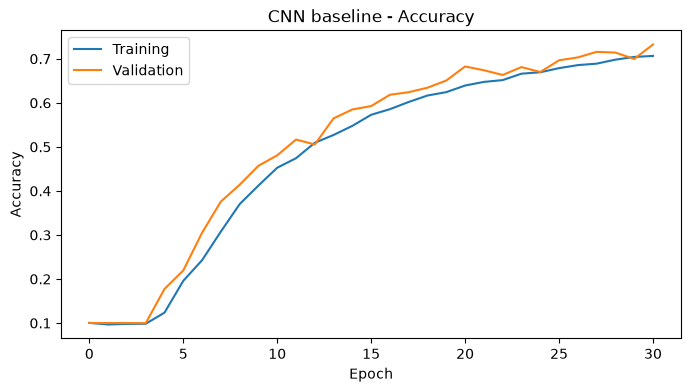

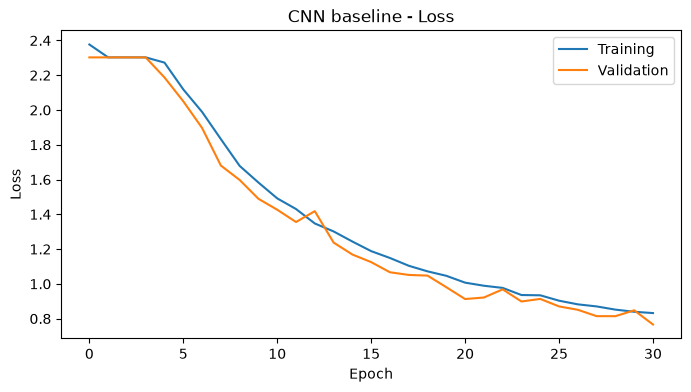

In [7]:
# Train the clean CNN baseline.
cnn_history = cnn.fit(
    x_train,
    y_train,
    batch_size=512,
    epochs=50,
    validation_data=(x_val, y_val),
    verbose=1,
    callbacks=Callbacks)

# Check whether training and validation curves diverge.
plot_training_history(cnn_history, "CNN baseline")
